<div align="center" style="display: inline-block; background: white; padding: 8px;">
  <img src="https://cdn.prod.website-files.com/633b44aa19e0eb425d7e8c7f/63724d646ecb4bd4cbdf7440_LOGO%20NUCLIO%20DIGITAL%20SCHOOL-01-01.png" alt="Nuclio Digital School" width="220">
</div>

# Fases proyecto ML

<div style="text-align: center;">
  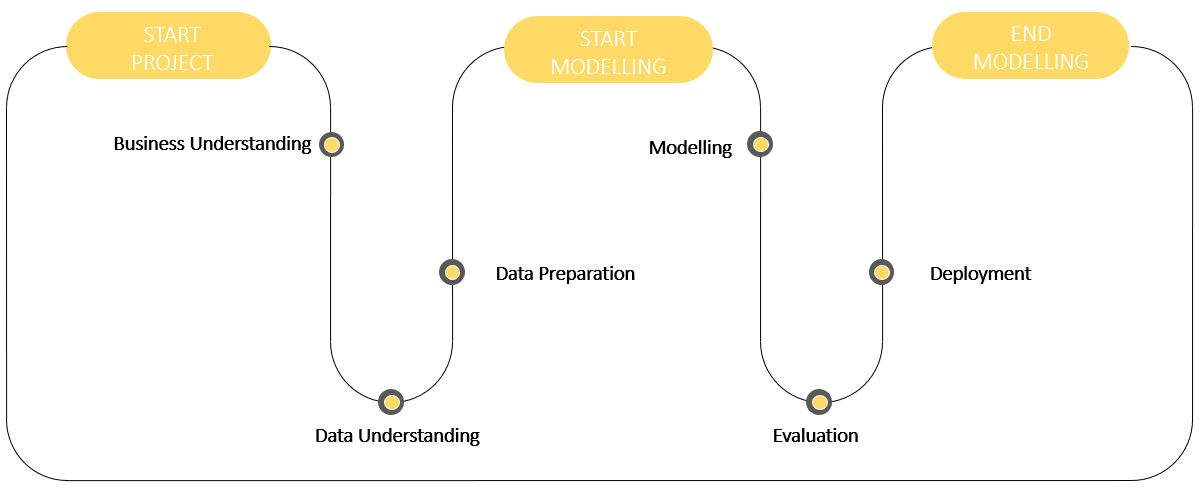
</div>

# Evaluación básica en ML
**Objetivos**
- Entender por qué evaluar es tan importante como entrenar.
- Diferenciar métricas y su interpretación en **clasificación** y **regresión**.
- Medir el rendimiento, detectar sobreajuste/subajuste y comparar modelos.

**Índice**
1. Split train/test y riesgo de overfitting  
2. Clasificación: accuracy y sus límites  
3. Regresión: MAE, MSE, RMSE, R²  


Evaluar un modelo de machine learning es fundamental porque permite medir qué tan bien el modelo funciona en datos no vistos, asegurando que sus predicciones sean precisas y confiables en situaciones reales.

Sin una evaluación adecuada, no sabríamos si el modelo solo memoriza los datos de entrenamiento o si realmente es capaz de generalizar y tomar decisiones correctas sobre nuevos datos.
Además, la evaluación ayuda a:
- Detectar problemas como sobreajuste (cuando el modelo se ajusta demasiado a los datos de entrenamiento y falla en datos nuevos).
- Mejorar el rendimiento del modelo identificando áreas débiles y optimizando sus parámetros.
- Generar confianza en los usuarios y stakeholders al garantizar que las decisiones se basan en resultados sólidos.

### Ejemplo 1 Árbol de decisión

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Feature columns: {load_breast_cancer().feature_names}")
print(f"\nTarget values: {load_breast_cancer().target_names}")

# Árbol poco restringido (propenso a overfitting)
deep_tree = DecisionTreeClassifier(random_state=42)  # sin max_depth
deep_tree.fit(X_train, y_train)
acc_train_deep = accuracy_score(y_train, deep_tree.predict(X_train))
acc_test_deep = accuracy_score(y_test, deep_tree.predict(X_test))

# Árbol regularizado
depth = 2
shallow_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
shallow_tree.fit(X_train, y_train)
acc_train_shallow = accuracy_score(y_train, shallow_tree.predict(X_train))
acc_test_shallow = accuracy_score(y_test, shallow_tree.predict(X_test))

print("\nÁrbol profundo   -> Accuracy train: %.3f | test: %.3f" % (acc_train_deep, acc_test_deep))
print("Árbol max_depth= %i -> Accuracy train: %.3f | test: %.3f" % (depth, acc_train_shallow, acc_test_shallow))

Feature columns: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target values: ['malignant' 'benign']

Árbol profundo   -> Accuracy train: 1.000 | test: 0.923
Árbol max_depth= 2 -> Accuracy train: 0.958 | test: 0.909


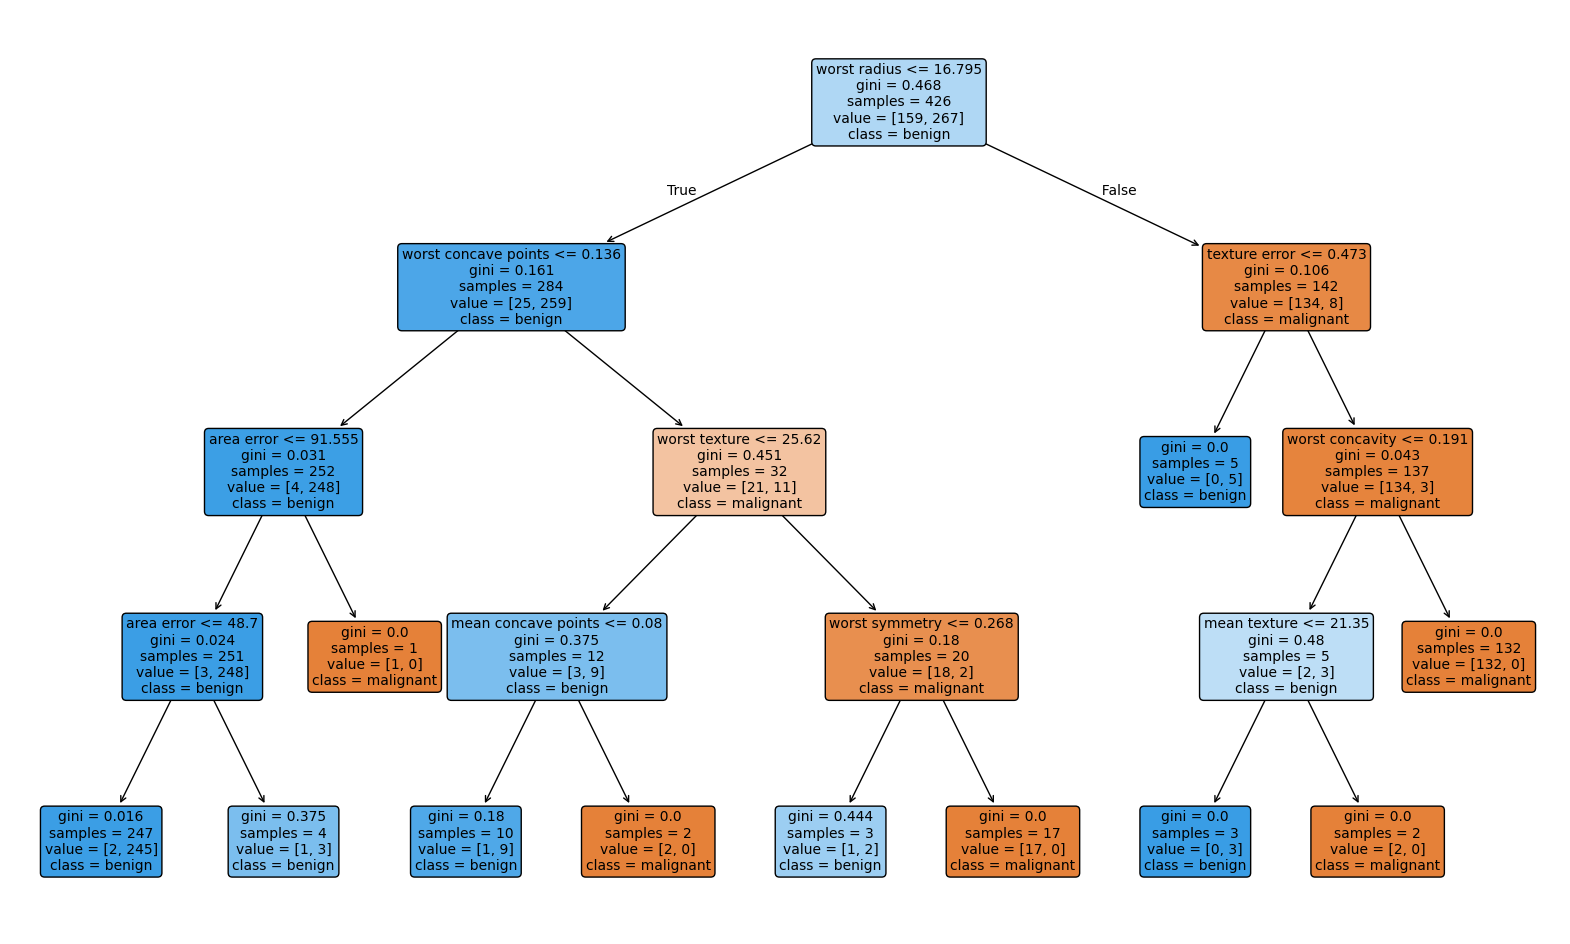

In [4]:
import matplotlib.pyplot as plt

# Mostrar el árbol de decisión
plt.figure(figsize=(20,12))
plot_tree(
    shallow_tree,
    filled=True,
    feature_names=load_breast_cancer().feature_names,
    class_names=load_breast_cancer().target_names,
    rounded=True,
    fontsize=10
)
plt.show()

# índice gini mide la pureza del nodo
# samples es el número de muestras analizadas en ese nodo
# value representa el conteo de muestras de cada clase
# class muestra la clase mayoritaria

Importancia de las características:
                         Importance
worst radius               0.809981
worst concave points       0.136084
texture error              0.053935
mean area                  0.000000
mean perimeter             0.000000
mean radius                0.000000
mean compactness           0.000000
mean concavity             0.000000
mean symmetry              0.000000
mean concave points        0.000000
mean fractal dimension     0.000000
radius error               0.000000
mean smoothness            0.000000
mean texture               0.000000
area error                 0.000000
perimeter error            0.000000
concavity error            0.000000
smoothness error           0.000000
concave points error       0.000000
symmetry error             0.000000
fractal dimension error    0.000000
compactness error          0.000000
worst texture              0.000000
worst perimeter            0.000000
worst smoothness           0.000000
worst area                 0

C:\Users\cde\AppData\Local\Temp\ipykernel_23200\2197697553.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y=feature_importances_clf.index, data=feature_importances_clf, palette='viridis')


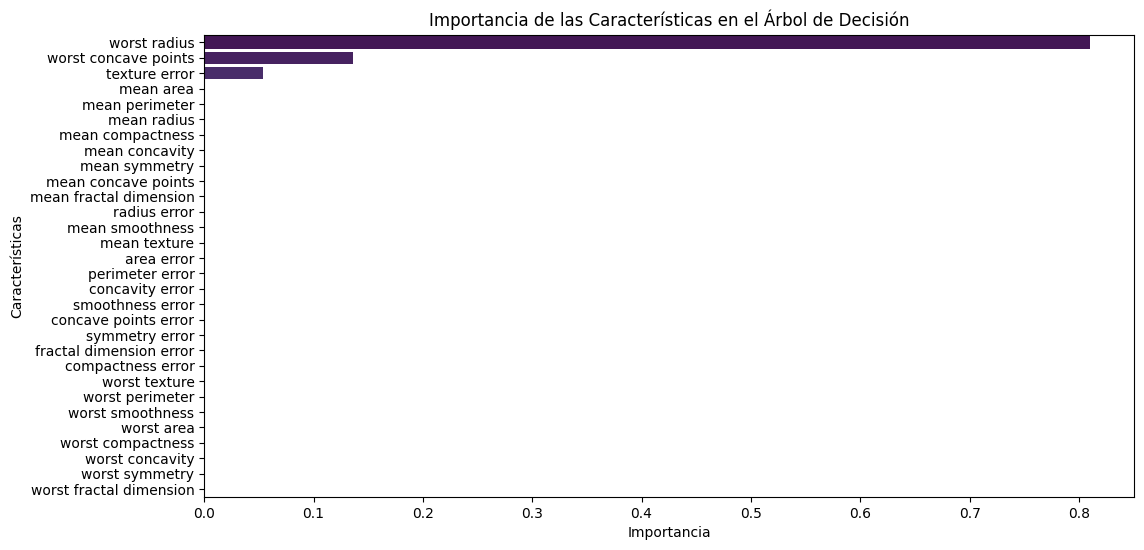

In [7]:
import pandas as pd
import seaborn as sns

# Crear DataFrame con importancias de características ordenadas
feature_importances_clf = pd.DataFrame(
    shallow_tree.feature_importances_, 
    index=load_breast_cancer().feature_names, 
    columns=['Importance']
).sort_values(by='Importance', ascending=False)

print("Importancia de las características:")
print(feature_importances_clf)

# Plot de la importancia de las características
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y=feature_importances_clf.index, data=feature_importances_clf, palette='viridis')
plt.title('Importancia de las Características en el Árbol de Decisión')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

### Ejemplo 2 Modelo trivial vs LogisticRegression

In [ ]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# make_classification sigue una distribución normal(0,1)
X_syn, y_syn = make_classification( n_samples=3000, 
                                    n_features=10,          #Crea 10 características (columnas) en total
                                    n_informative=5,        #Solo 5 de las 10 características son realmente útiles para la clasificación
                                    weights=[0.95, 0.05],   #Desbalanceo de clases: 95% clase 0, 5% clase 1 (Generación aleatoria)
                                    random_state=0)

In [32]:
import pandas as pd

# Convertir a DataFrame para mejor visualización
df = pd.DataFrame(X_syn)
print(df)

# Con nombres de columnas
df = pd.DataFrame(X_syn, columns=[f'Col_{i}' for i in range(X_syn.shape[1])])
print(df.head(10))  # Primeras 10 filas

             0         1         2         3         4         5         6  \
0     0.551890  0.502965  0.008838  1.275570 -0.636291  0.204991 -0.641438   
1     1.664670 -0.334373  1.051210 -0.195847  1.510383  1.235555  0.509677   
2     0.679392  0.816741  0.820792  1.153407  0.222338  1.274302 -0.103165   
3     0.588554  1.387142  0.646103 -1.776500  0.348179  0.288851  0.081470   
4     1.925360 -3.378714  0.660975 -0.377428 -0.445843  1.497915 -3.341504   
...        ...       ...       ...       ...       ...       ...       ...   
2995 -1.569545  1.256645  1.515683  0.312332  0.039563  2.058917 -3.430560   
2996  0.974902 -0.334774 -1.592189  0.956508  0.003971  3.762763 -3.134547   
2997 -0.588244  1.259564  0.481152 -0.071350  1.182610  1.133778 -1.597239   
2998  1.161023  1.145031  0.912931  1.043709 -1.199840  1.355596 -0.438163   
2999  0.545004  1.778793  0.916950  1.433232  0.633085  1.388781  0.771074   

             7         8         9  
0     0.011327 -1.881832  

In [33]:
# Verificar distribución real
unique, counts = np.unique(y_syn, return_counts=True)
print(f"Clase 0: {counts[0]} ({counts[0]/3000:.4f})")
print(f"Clase 1: {counts[1]} ({counts[1]/3000:.4f})")

Clase 0: 2839 (0.9463)
Clase 1: 161 (0.0537)


In [39]:
# Modelo trivial: siempre predice la clase mayoritaria (0)
y_dummy = np.zeros_like(y_syn)
acc_dummy = accuracy_score(y_syn, y_dummy)

# Modelo entrenado
Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.3, random_state=0, stratify=y_syn)
clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr, ytr)
yp = clf.predict(Xte)
acc_log = accuracy_score(yte, yp)

print("Accuracy modelo trivial (mayoría):", acc_dummy)
print("Accuracy Logistic Regression:", acc_log)

Accuracy modelo trivial (mayoría): 0.9463333333333334
Accuracy Logistic Regression: 0.9777777777777777


## Métricas fundamentales de Evaluación

<div style="text-align: center;">
  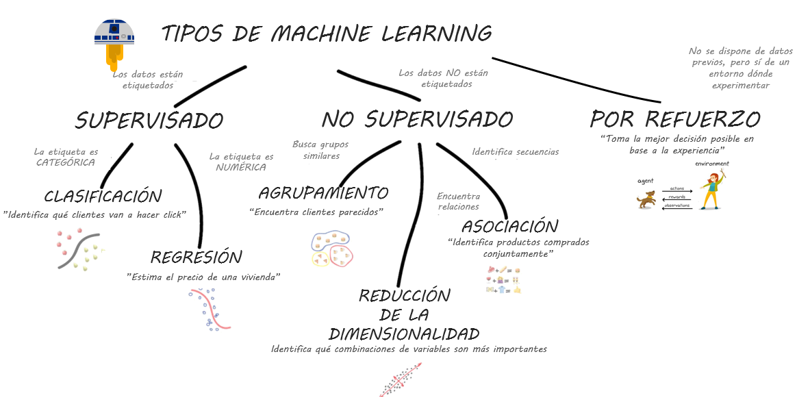
</div>

## Métricas para problemas de clasificación

En clasificación, no basta con mirar la accuracy. Dependiendo del problema, otras métricas pueden ser más relevantes, sobre todo cuando las clases están desbalanceadas.


#### **1. Matriz de confusión**
Es una tabla que compara las predicciones del modelo con los valores reales:
- TP (True Positive): positivos predichos correctamente  
- TN (True Negative): negativos predichos correctamente  
- FP (False Positive): negativos clasificados como positivos  
- FN (False Negative): positivos clasificados como negativos

<div style="text-align: center;">
  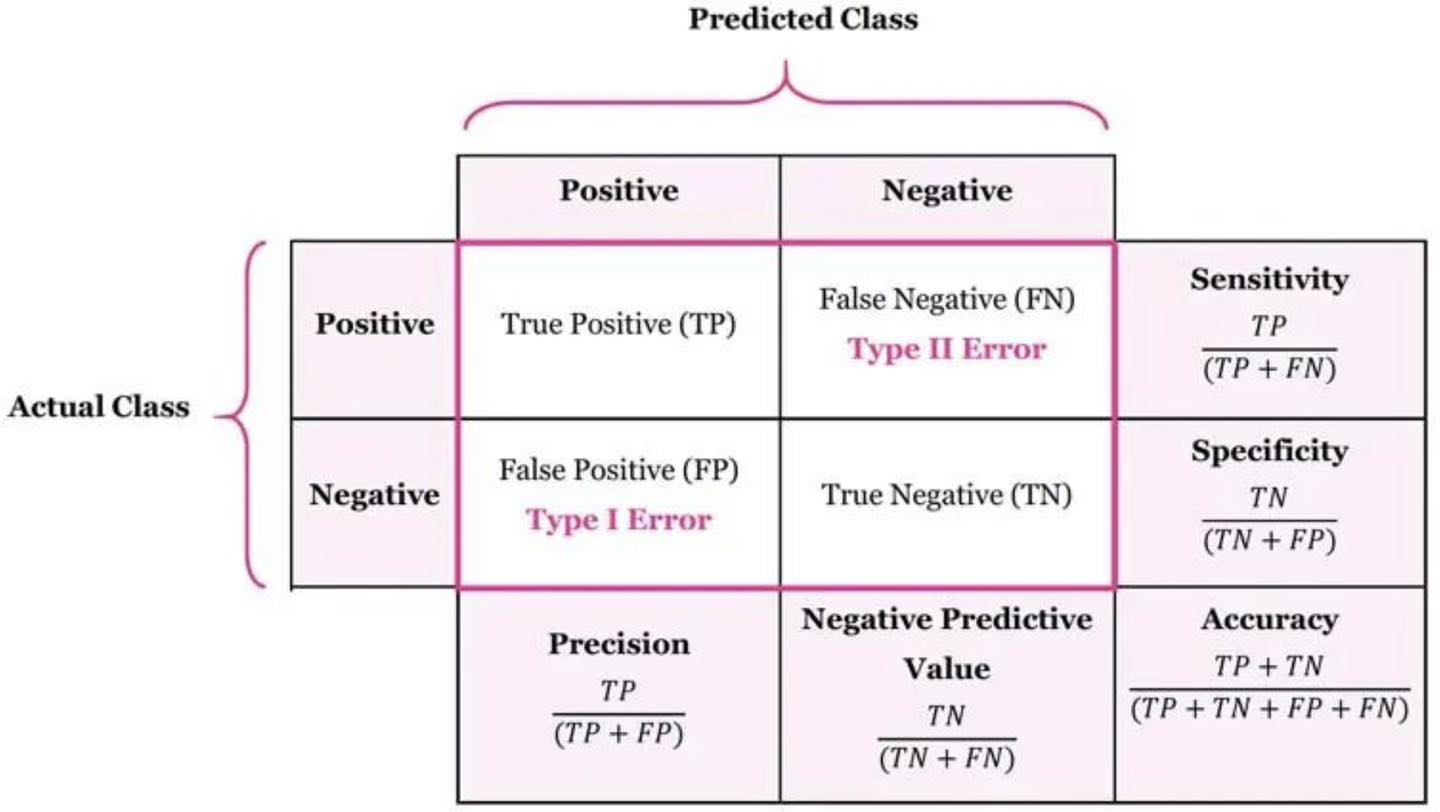
</div>

Ejemplo: detectar spam en emails  
- TP: correos spam detectados como spam  
- FN: correos spam que pasan como normales  
- FP: correos normales detectados como spam (molesto para el usuario)  
- TN: correos normales detectados como normales  

Ejemplo: detectar embarazos

<div style="text-align: center;">
  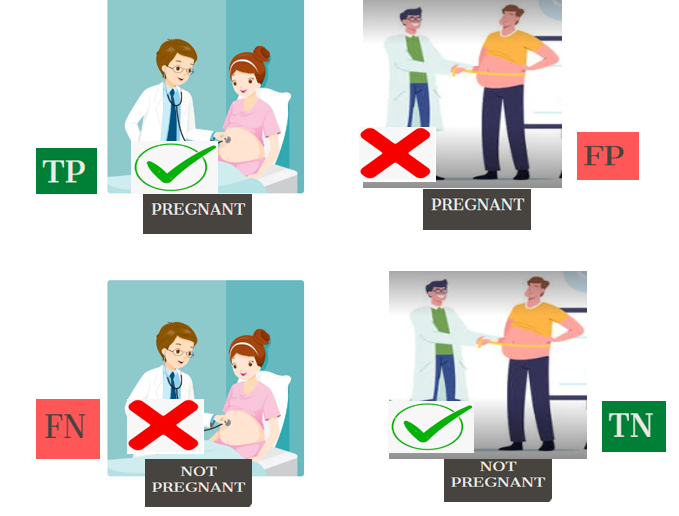
</div>

#### **2. Accuracy (exactitud)**
Se calcula mediante la fórmula:
$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Proporción de aciertos sobre todos los casos.  
⚠️ Problema: puede ser engañosa con clases muy desbalanceadas (ej: si 95% de los emails son “no spam”, un modelo que siempre diga “no spam” tendrá 95% de accuracy).



#### **3. Precision** -> columna
Se calcula mediante la fórmula:
$$
Precision = \frac{TP}{TP + FP}
$$

Se interpreta como: "De todos los que predije como positivos, ¿cuántos lo eran realmente?"

Ejemplo: en detección de spam, alta precisión significa que casi todos los correos marcados como spam lo son.



#### **4. Recall (sensibilidad)** -> fila
Se calcula mediante la fórmula:
$$
Recall = \frac{TP}{TP + FN}
$$

Se interpreta como: "De todos los positivos reales, ¿cuántos detecté correctamente?"

Ejemplo: en detección de cáncer, queremos un recall alto (detectar la mayor cantidad de enfermos, aunque tengamos algunos falsos positivos).



#### 5. F1-score
$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

Es la media armónica entre **precision** y **recall**.  
Equilibra ambas métricas cuando necesitamos un compromiso entre evitar falsos positivos y no dejar escapar verdaderos positivos.


#### **6. Macro Average (Promedio Macro)** 
El promedio macro calcula la métrica de interés para cada clase y luego promedia estos valores. No tiene en cuenta el desequilibrio de clases.

#### **7. Weighted Average (Promedio Ponderado)** 
El promedio ponderado calcula la métrica de interés para cada clase y luego promedia estos valores, ponderado por el soporte (número de instancias de cada clase). Tiene en cuenta el desequilibrio de clases.

<div style="background-color:#fff3cd; padding:10px; border-left:4px solid #ffc107; margin:10px 0; color:#2c3e50;">
<strong>⚠️ Nota:</strong> Se extiende un ejemplo con más detalle en el notebook clasificacion_matriz_confusion.ipynb
</div>

### **Resumen práctico**
- **Accuracy**: buena solo si las clases están balanceadas.  
- **Precision**: útil cuando los falsos positivos son muy costosos (ej: alertas falsas en seguridad).  
- **Recall**: útil cuando los falsos negativos son muy costosos (ej: diagnósticos médicos).  
- **F1**: buen equilibrio en problemas desbalanceados.  

#### 6. ROC y AUC
- La curva **ROC** (Receiver Operating Characteristic) muestra la relación entre *TPR (recall)* y *FPR (tasa de falsos positivos)* para distintos umbrales.  
- El área bajo la curva (**AUC**) mide la capacidad del modelo para separar las clases (1 = perfecto, 0.5 = azar).



#### 7. Precision-Recall Curve (PR)
Más informativa cuando las clases están **muy desbalanceadas**.  
Muestra el compromiso entre *precision* y *recall* para distintos umbrales.


- **ROC-AUC**: mide la discriminación global del modelo.  
- **PR Curve**: mejor que ROC en datasets desbalanceados.

## Métricas para problemas de regresión

En regresión, la evaluación no usa accuracy. Para evaluar modelos de regresión es fundamental usar métricas que midan la diferencia entre los valores predichos y los valores reales. Las métricas más comunes son:
### Mean squared error
Promedio de los cuadrados de las diferencias entre valores reales y predichos. Penaliza fuertemente los errores grandes.
$$
\mathrm{MSE} = \frac{1}{n} \sum_{t=1}^{n} e_t^2
$$

### Root mean squared error
Raíz cuadrada del MSE, en las mismas unidades que la variable objetivo, facilitando interpretación.
$$
\mathrm{RMSE} = \sqrt{ \frac{1}{n} \sum_{t=1}^{n} e_t^2 }
$$

### Mean absolute error
Promedio de las diferencias absolutas entre valores reales y predichos. Es más robusto frente a valores atípicos que el MSE.
$$
\mathrm{MAE} = \frac{1}{n} \sum_{t=1}^{n} | e_t |
$$

### Mean absolute percentage error
Expresa el error absoluto promedio como un porcentaje de los valores reales, y es útil para interpretar el desempeño de un modelo en términos relativos.
$$
\mathrm{MAPE} = \frac{100\%}{n} \sum_{t=1}^{n} \left| \frac{e_t}{y_t} \right|
$$

### $R^2$
Mide la proporción de la varianza explicada por el modelo, con valores entre 0 y 1 (aproximadamente). Un valor cercano a 1 indica buen ajuste.

La fórmula para calcular el coeficiente de determinación $ R^2 $ de un modelo de regresión es:

$$
R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
$$

donde:
- $SS_{res} = \sum (y_i - \hat{y}_i)^2$ es la suma de los cuadrados de los residuos (errores) del modelo,
- $SS_{tot} = \sum (y_i - \bar{y})^2$ es la suma total de los cuadrados, es decir, la variabilidad total en los valores observados de $y$,
- $y_i$ son los valores observados,
- $\hat{y}_i$ son los valores predichos por el modelo,
- $\bar{y}$ es la media de los valores observados.

Un valor de $ R^2 $ igual a 0 indica que el modelo de regresión no explica ninguna variabilidad de los datos y que la predicción del modelo es equivalente a simplemente usar la media de los valores observados para todos los casos

Como resumen general:
- **MAE**: es preferible cuando los errores puntuales importantes no son críticos, y se quiere medir error medio general. (robusto a outliers).
- **MSE**/**RMSE**: son útiles cuando se quiere penalizar más los errores grandes,.
- **R²**: complementa las otras métricas indicando cómo de bien el modelo explica la variabilidad del dataset.

In [11]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Xd, yd = load_diabetes(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.25, random_state=42)

reg = LinearRegression()
reg.fit(Xtr, ytr)
pred = reg.predict(Xte)

mae = mean_absolute_error(yte, pred)
mse = mean_squared_error(yte, pred)
rmse = np.sqrt(mse)
r2 = r2_score(yte, pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 41.54850685988059
MSE: 2848.3106508475043
RMSE: 53.36956671032195
R²: 0.4849058889476757


# Sesgos en ML
Error sistemático o patrón distorsionado en los datos o modelos que haga que las predicciones o resultados favorezcan o perjudiquen de forma injustificada alguna característica, clase o categoría.

Fairness o equidad en ML se define como la ausencia de discriminación hacia individuos o grupos basada en características sensibles.

Sesgos según el origen:
1. **Sesgos en los datos**
Se refiere a problemas en la calidad, representatividad o integridad de los datos de entrenamiento.
- Subrepresentación
- Muestreo no aleatorio
- Variables proxy
- Medición
- Histórico
•	El sesgo en los datos es la causa primaria y más común del sesgo algorítmico


2. **Sesgos en los algoritmos**
El sesgo algorítmico puede amplificar, perpetuar e incluso generar sesgos adicionales por decisiones técnicas y conceptuales en el diseño del modelo
- Sesgo de amplificación
- Sesgo por construcción

3. Sesgo ..... (Pista: hay tantas versiones de un hecho como observadores) 

Métricas asociadas a la equidad:

#### **True positive rate (TPR)**
Se calcula mediante la fórmula:
$$
TPR = \frac{TP}{TP + FN}
$$

#### **False positive rate (FPR)**
Se calcula mediante la fórmula:
$$
FPR = \frac{FP}{FP + TN}
$$

#### **Selection rate**
Proporción de veces que el modelo predice positivo para ese grupo, sin mirar la etiqueta. Se calcula mediante la fórmula:
$$
\text{Selection rate} = \frac{\# \text{predicciones positivas}}{\text{total de muestras en el grupo}}
$$


Ejemplo: Cómo usar sklearn.datasets

In [9]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# data = load_breast_cancer()
# X = data.data
# y = data.target

X_, y_ = load_breast_cancer(return_X_y=True) #Devuelve directamente dos arrays: características (X) y etiquetas (y)

In [9]:
X == X_

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(569, 30))

In [14]:
import numpy as np

different_count = np.sum(y != y_)
print(f"Elementos diferentes: {different_count}")

Elementos diferentes: 0


In [10]:
X, y = load_breast_cancer(return_X_y=True)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

pipe.fit(X_train, y_train)
y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

print("Accuracy (train):", accuracy_score(y_train, y_pred_train))
print("Accuracy (test): ", accuracy_score(y_test, y_pred_test))


Accuracy (train): 0.9882629107981221
Accuracy (test):  0.986013986013986
